# M1-B1 — Réentraînement Pyrenex Crédit (template)

> Duplique ce notebook en `M1-B1_<prenom>_scoring.ipynb` et travaille dessus.

**Objectif** : reproduire et challenger la baseline `pyrenex-risk-v1` sur le nouveau dataset Lending Club.

**Compétence visée** : C5 — imiter.

## 0. Setup

In [21]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
DATA_DIR = Path('../data')

## 1. Comprendre la baseline `pyrenex-risk-v1`

**Métriques de référence (test split 20% de 12k)** : F1 macro = 0.5018, ROC-AUC = 0.7296.

**Features** : 14 colonnes  — `loan_amnt`, `term`, `int_rate`, `installment`, `grade`, `emp_length`, `home_ownership`, `annual_inc`, `verification_status`, `purpose`, `dti`, `delinq_2yrs`, `fico_range_low`, `revol_util`.

**Architecture** : RandomForest (`n_estimators=100`, `max_depth=None`).

## 2. EDA du nouveau dataset

In [33]:
df = pd.read_csv(DATA_DIR / 'lending_club_train.csv')
print(df.shape)
print(df.head(5))
print(df.dtypes)
# term et emp_length sont en object alors que ce sont des nombres

print(df.isna().mean().sort_values(ascending=False).head(10))
# taux de NaN : emp_length 3,97 % / revol_util 1,62 % / le reste 0

print(df.info())
print(df["loan_status"].value_counts())

(24000, 15)
   loan_amnt       term  int_rate  installment grade emp_length  \
0       5700  36 months      6.71       175.24     A    3 years   
1       8700  36 months     11.83       288.26     C    3 years   
2       7900  36 months     11.25       259.57     C    5 years   
3      35800  36 months      9.61      1148.62     B    3 years   
4      16000  60 months     14.43       375.87     C    8 years   

  home_ownership  annual_inc verification_status             purpose    dti  \
0       MORTGAGE       38900        Not Verified      small_business  17.92   
1           RENT       51400            Verified    home_improvement  21.26   
2           RENT       38900            Verified  debt_consolidation  13.56   
3       MORTGAGE       82900            Verified         credit_card  29.99   
4       MORTGAGE       32700        Not Verified    home_improvement  17.98   

   delinq_2yrs  fico_range_low  revol_util loan_status  
0            0             738        78.1  Fully Pai

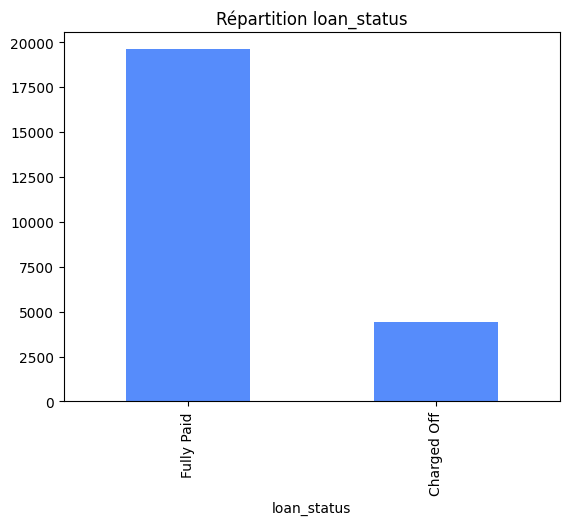

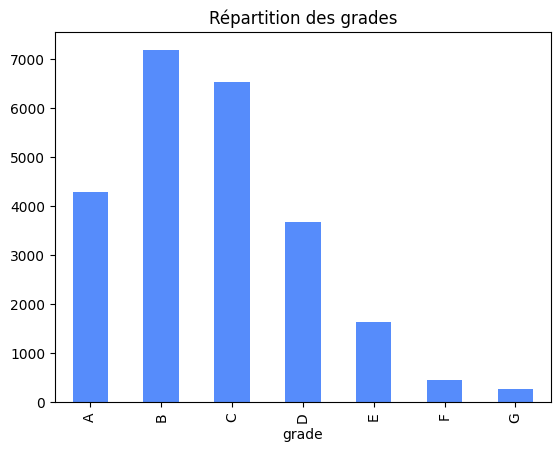

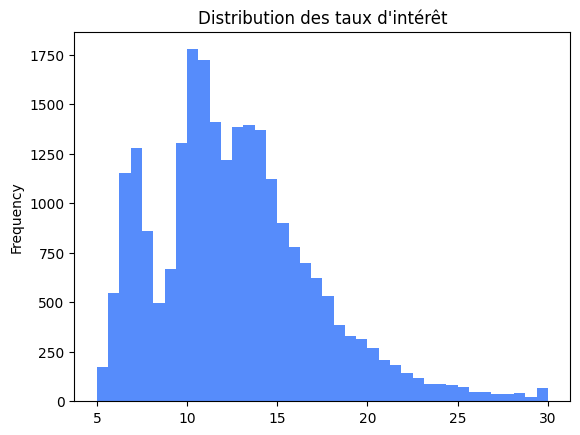

In [32]:
df["loan_status"].value_counts().plot(kind="bar", title="Répartition loan_status")
plt.show()

df["grade"].value_counts().sort_index().plot(kind="bar", title="Répartition des grades")
plt.show()

df["int_rate"].plot(kind="hist", bins=40, title="Distribution des taux d'intérêt")
plt.show()

### Ce qui change par rapport à 2017

- Le dataset est deux fois plus gros qu'en 2017 (24 000 lignes contre 12 000).
- Il y a plus de mauvais payeurs : environ 18 % de défauts, contre 15 % avant.
- Il y a maintenant des trous dans les données : 4 % sur emp_length et 1,6 % sur revol_util, alors qu'en 2017 tout était rempli.
- Les emprunteurs sont plus risqués : un quart d'entre eux ont un grade D à G, c'est plus qu'avant.
- Les taux d'intérêt suivent : ils sont tirés vers le haut à cause de ces profils plus risqués.

## 3. Préparation et split

Split stratifié, `random_state=42`.

In [ ]:
%%sql


In [ ]:
y = df["loan_status"].map({"Fully Paid": 0, "Charged Off": 1})
X = df.drop(columns=["loan_status"])


## 4. Entraînement + benchmark

Au moins 2 jeux d'hyperparamètres. Trace chaque run dans `../experiments.md`.

## 4bis. Le score est-il stable ?

> Avant de comparer deux modèles ou de défendre un chiffre devant Pyrenex, vérifie une chose : **est-ce que ton F1 dépend du découpage train/test ?** Si le score varie déjà beaucoup en changeant juste la `random_state` du split, un gain de +0.005 entre deux modèles est probablement du bruit, pas un vrai progrès.

Lance la boucle ci-dessous avec le modèle entraîné en section 4. Si l'écart entre seeds dépasse l'écart entre tes deux jeux d'hyperparamètres, il faudra passer à la validation croisée (qu'on verra en M2).

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

# TODO : adapte aux noms de tes variables (X, y, et le modèle de la section 4)
scores = []
for seed in [0, 1, 42, 100, 2024]:
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=seed
    )
    model = ...  # ré-instancie le même modèle qu'en section 4
    model.fit(X_tr, y_tr)
    f1 = f1_score(y_te, model.predict(X_te), average='macro')
    scores.append(f1)
    print(f"seed={seed:>4} → F1 macro = {f1:.3f}")

print(f"\nÉcart min-max : {max(scores) - min(scores):.3f}")

**Interprétation** :
- Écart min-max < 0.01 → ton score est stable, tu peux comparer deux modèles sereinement.
- Écart min-max > 0.02 → tes scores sont bruités par le découpage. Un gain inférieur à cet écart entre deux modèles n'est **pas significatif**, c'est probablement de la chance.

> Pour aller plus loin (on verra en M2) : `cross_val_score` fait ce travail proprement en 1 ligne, sur k folds, et te donne moyenne ± écart-type.

## 5. Évaluation sur holdout

F1 macro, F1 défaut, ROC-AUC, matrice de confusion, classification report.

## 6. Verdict

Synthèse à recopier dans `../verdict.md`.

## ⭐ Mission étoile optionnelle

Variante A : Gradient Boosting + SHAP. Variante B : Fine-tuning SLM sur `purpose`.